# **Echo Vision** 
## **Approach 2: using Google GenAI library and HuggingFace Transformers pipeline**

In [1]:
# ! pip install torch torchvision

In [2]:
# ! pip install transformers tokenizers accelerate

In [3]:
# ! pip install pillow matplotlib timm

In [4]:
# ! pip install google-genai

### **1. Image Captioning using Google GenAI SDK**

#### **1.1 Input Image**

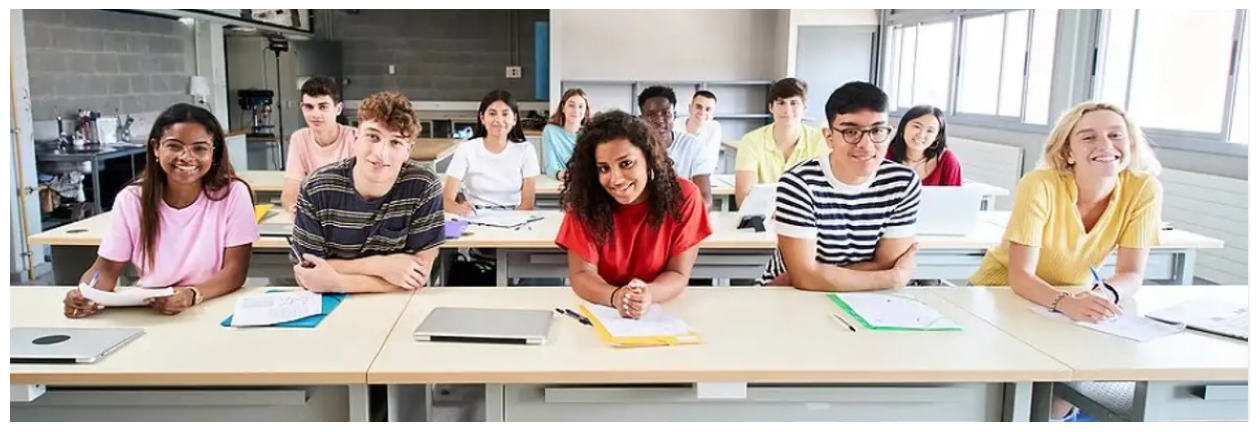

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = "images\\classroom.jpg"  
loadedImage = Image.open(image_path)

# Display the image
plt.figure(figsize=(16, 9))
plt.imshow(loadedImage)
plt.axis('off') 
plt.show()

#### **1.2 Setup the Gemini Client**

In [6]:
from google import genai

keyFile = open("keys/.gemini.txt")
key = keyFile.read()
keyFile.close()

client = genai.Client(api_key=key)

#### **1.3 Image Captioning**

In [7]:
from google import genai
from google.genai import types

# System prompt and model parameters
custom_config = types.GenerateContentConfig(
    system_instruction="""You are a helpful AI Assistant. 
    Given an image perform object detection and provide a text output which contains the information about the labels detected 
    and their counts.""",
    temperature=1,
    top_p=0.8,
)

# Read the image file as bytes
with open(image_path, 'rb') as f:
  image_bytes = f.read()

# Create a content part with the image bytes
context = [
    types.Part.from_bytes(
        data=image_bytes,
        mime_type='image/jpeg',
    ),
    # types.Part.from_text(
    #     text="Explain the image to a blind person in a short and concise way."
    # )
]

# Generate content 
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    config=custom_config,
    contents=context,
)

captionOutput = response.text
print(captionOutput)

The image displays a group of students in a classroom setting, likely a laboratory or workshop, given the equipment visible in the background. Here is the count of the detected objects:

* **person**: 12
* **laptop**: 4
* **desk**: 3 (long rows of tables)
* **paper**: 6 (sets of papers or notebooks on the desks)
* **pen**: 6 (visible pens being held or lying on desks)


### **2. Text Processing**

In [8]:
from google import genai
from google.genai import types

# System prompt and model parameters
contentLength = "brief" #@ ["brief", "detailed"]
tone = "formal" #@ ["formal", "informal", "humorous"]

custom_config = types.GenerateContentConfig(
    system_instruction=f"""You are a helpful AI Assistant who summarizes the given input into a {contentLength} and {tone} content for a blind person. 
    Add a very short welcome note at the beginning to make the content more engaging.
    (e.g., "Here is what I see in the image...")""",
    temperature=1,
    top_p=0.8,
)

# Create a content part with the image bytes
context = [    
    types.Part.from_text(
        text=f"{captionOutput}"
    )
]

# Generate content 
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    config=custom_config,
    contents=context,
)

processedCaptionOutput = response.text
print(processedCaptionOutput)

Hello! Here is what I see in the image.

The scene depicts a classroom or laboratory environment containing twelve students engaged in a learning session. They are seated at three long desks equipped with four laptops, six sets of papers or notebooks, and six pens. The setting suggests a collaborative workshop or a practical academic lesson.


### **3. Text to Speech**

In [15]:
# Create audio pipeline
from transformers import pipeline

synthesizer = pipeline(
    task="text-to-speech", 
    model="suno/bark-small",
    )

Loading weights: 100%|██████████| 542/542 [00:00<00:00, 807.80it/s, Materializing param=semantic.position_embeds_layer.weight]                                        
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.1.weight to fine_acoustics.lm_heads.0.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.2.weight to fine_acoustics.lm_heads.1.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.3.weight to fine_acoustics.lm_heads.2.weight, but both are present in the checkpoints, so we will NOT tie them. You should updat

In [16]:
# Generate audio from the label summary
processedCaptionOutputAudio = synthesizer(processedCaptionOutput)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

In [17]:
# play the audio
from IPython.display import Audio as IPythonAudio

IPythonAudio(
    processedCaptionOutputAudio["audio"],
    rate=processedCaptionOutputAudio["sampling_rate"]
)